# Research01 Baseline Pipeline

`data/raw_data/Research01.ipynb`의 흐름을 기준으로 baseline 이상 탐지 실험을 정리한 노트북입니다.

구성 순서:
1. 데이터 로딩 정리
2. train/test 구조 명확화
3. feature 컬럼 고정
4. scaling
5. sliding window 생성
6. 원본 데이터만으로 baseline 모델 학습
7. baseline 성능 평가

## 0. 환경 설정

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif ROOT.name == "raw_data":
    ROOT = ROOT.parents[1]
elif ROOT.name == "data":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw_data"
RAW_TRAIN_DIR = RAW_DIR / "train"
RAW_TEST_DIR = RAW_DIR / "test"
LABEL_DIR = ROOT / "data" / "preprocessed" / "test"

BASELINE_DIR = ROOT / "data" / "baseline"
WINDOWED_DIR = ROOT / "data" / "windowed" / "baseline_scaled"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
WINDOWED_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("ROOT:", ROOT)
print("RAW_DIR exists:", RAW_DIR.exists())

ROOT: C:\Users\gram\Desktop\Research
RAW_DIR exists: True


## 1. 데이터 로딩 정리

원본 CSV를 읽고 컬럼 공백 제거, `WorkingTime` 변환, 시간 순 정렬을 수행합니다. 원본 파일은 덮어쓰지 않습니다.

In [2]:
def load_sensor_csv(path: Path, default_label: int | None = None) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    if "WorkingTime" in df.columns:
        df["WorkingTime"] = pd.to_datetime(df["WorkingTime"].astype(str).str.strip(), errors="coerce")
        df = df.sort_values("WorkingTime").reset_index(drop=True)
        df["ElapsedSeconds"] = (df["WorkingTime"] - df["WorkingTime"].min()).dt.total_seconds()

    if "label" not in df.columns and default_label is not None:
        df["label"] = default_label

    if "label" in df.columns:
        df["label"] = df["label"].astype(int)

    df["source_file"] = path.name
    return df


def load_ng_labeled(name: str) -> pd.DataFrame:
    labeled_path = RAW_TEST_DIR / f"{name}_labeled.csv"
    if labeled_path.exists():
        return load_sensor_csv(labeled_path)

    raw_path = RAW_TEST_DIR / f"{name}.csv"
    label_path = LABEL_DIR / f"{name}_Label.csv"
    raw = pd.read_csv(raw_path)
    label = pd.read_csv(label_path)
    raw.columns = raw.columns.str.strip()
    label.columns = label.columns.str.strip()

    if "Unnamed: 0" in label.columns:
        label = label.drop(columns=["Unnamed: 0"])

    if len(raw) != len(label):
        raise ValueError(f"Row count mismatch: {raw_path.name}={len(raw)} vs {label_path.name}={len(label)}")

    merged = pd.concat([raw.reset_index(drop=True), label.reset_index(drop=True)], axis=1)
    merged.to_csv(labeled_path, index=False)
    return load_sensor_csv(labeled_path)


train_df = load_sensor_csv(RAW_TRAIN_DIR / "Training_Data.csv", default_label=0)
ok1_df = load_sensor_csv(RAW_TEST_DIR / "WeldingTest_01_OK.csv", default_label=0)
ok2_df = load_sensor_csv(RAW_TEST_DIR / "WeldingTest_02_OK.csv", default_label=0)
ng3_df = load_ng_labeled("WeldingTest_03_NG")
ng4_df = load_ng_labeled("WeldingTest_04_NG")

display(train_df.head())
display(ng3_df.head())

,PageNo,Speed,Length,RealPower,SetFrequency,SetDuty,SetPower,GateOnTime,WorkingTime,ElapsedSeconds,label,source_file
0,1,250,241.1,1688,1000,100,82,1154,2022-01-08 10:11:45.181,0.000,0,Training_Data.csv
1,2,250,241.2,1713,1000,100,83,1670,2022-01-08 10:11:48.487,3.306,0,Training_Data.csv
2,3,250,241.1,1695,1000,100,82,1153,2022-01-08 10:11:51.245,6.064,0,Training_Data.csv
3,4,250,241.2,1717,1000,100,83,1670,2022-01-08 10:11:54.493,9.312,0,Training_Data.csv
4,5,250,241.1,1698,1000,100,82,1154,2022-01-08 10:11:57.269,12.088,0,Training_Data.csv


,PageNo,Speed,Length,RealPower,SetFrequency,SetDuty,SetPower,GateOnTime,WorkingTime,label,ElapsedSeconds,source_file
0,1,250,241.1,1660,1000,100,82,1154,2022-08-03 09:10:24.996,0,0.000,WeldingTest_03_NG_labeled.csv
1,2,250,241.2,1685,1000,100,83,1670,2022-08-03 09:10:28.312,0,3.316,WeldingTest_03_NG_labeled.csv
2,3,250,241.1,1666,1000,100,82,1153,2022-08-03 09:10:31.076,0,6.080,WeldingTest_03_NG_labeled.csv
3,4,250,241.2,1690,1000,100,83,1670,2022-08-03 09:10:34.284,0,9.288,WeldingTest_03_NG_labeled.csv
4,5,250,241.1,1670,1000,100,82,1154,2022-08-03 09:10:37.046,0,12.050,WeldingTest_03_NG_labeled.csv


## 2. train/test 구조 명확화

- train: `Training_Data.csv`, 정상 데이터로 가정하여 `label=0`
- test normal: `WeldingTest_01_OK.csv`, `WeldingTest_02_OK.csv`, `label=0`
- test anomaly 포함: `WeldingTest_03_NG_labeled.csv`, `WeldingTest_04_NG_labeled.csv`, 제공 라벨 사용

In [3]:
test_df = pd.concat([ok1_df, ok2_df, ng3_df, ng4_df], ignore_index=True)

split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_df),
        "normal": int((train_df["label"] == 0).sum()),
        "anomaly": int((train_df["label"] == 1).sum()),
        "files": "Training_Data.csv",
    },
    {
        "split": "test",
        "rows": len(test_df),
        "normal": int((test_df["label"] == 0).sum()),
        "anomaly": int((test_df["label"] == 1).sum()),
        "files": ", ".join(test_df["source_file"].drop_duplicates()),
    },
])

display(split_summary)
display(test_df.groupby(["source_file", "label"]).size().reset_index(name="count"))

,split,rows,normal,anomaly,files
0,train,135759,135759,0,Training_Data.csv
1,test,5226,4934,292,"WeldingTest_01_OK.csv, WeldingTest_02_OK.csv, ..."


,source_file,label,count
0,WeldingTest_01_OK.csv,0,1950
1,WeldingTest_02_OK.csv,0,1872
2,WeldingTest_03_NG_labeled.csv,0,1034
3,WeldingTest_03_NG_labeled.csv,1,19
4,WeldingTest_04_NG_labeled.csv,0,78
5,WeldingTest_04_NG_labeled.csv,1,273


## 3. feature 컬럼 고정

`Research01.ipynb` 후반부 선택을 반영하여 5개 feature를 고정합니다.

- `RealPower`
- `GateOnTime`
- `SetPower`
- `Speed`
- `Length`

`PageNo`, `WorkingTime`, `ElapsedSeconds`, `label`은 모델 입력에서 제외합니다.

In [4]:
FEATURES = ["RealPower", "GateOnTime", "SetPower", "Speed", "Length"]

missing_train = [col for col in FEATURES if col not in train_df.columns]
missing_test = [col for col in FEATURES if col not in test_df.columns]
if missing_train or missing_test:
    raise ValueError(f"Missing features. train={missing_train}, test={missing_test}")

feature_summary = pd.DataFrame({
    "feature": FEATURES,
    "train_unique": [train_df[col].nunique() for col in FEATURES],
    "test_unique": [test_df[col].nunique() for col in FEATURES],
    "train_missing": [train_df[col].isna().sum() for col in FEATURES],
    "test_missing": [test_df[col].isna().sum() for col in FEATURES],
})
display(feature_summary)

train_df[FEATURES].describe().T

,feature,train_unique,test_unique,train_missing,test_missing
0,RealPower,71,84,0,0
1,GateOnTime,9,4,0,0
2,SetPower,3,4,0,0
3,Speed,6,2,0,0
4,Length,4,3,0,0


,count,mean,std,min,25%,50%,75%,max
RealPower,135759.0,1310.510780,493.224711,0.0,688.0,1688.0,1704.0,1733.0
GateOnTime,135759.0,1117.989651,421.956610,650.0,650.0,1154.0,1670.0,1670.0
SetPower,135759.0,65.384615,21.653072,38.0,38.0,82.0,83.0,83.0
Speed,135759.0,165.013811,106.977945,30.0,30.0,250.0,250.0,250.0
Length,135759.0,155.534759,107.806431,19.4,19.4,241.1,241.2,241.2


## 4. scaling

스케일러는 train 데이터에만 `fit`합니다. test 데이터에는 train 기준 스케일러를 `transform`만 적용합니다.

In [5]:
scaler = StandardScaler()

train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[FEATURES] = scaler.fit_transform(train_df[FEATURES])
test_scaled[FEATURES] = scaler.transform(test_df[FEATURES])

display(train_scaled[FEATURES].describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
RealPower,-2.403386e-16,1.000004,-2.657036,0.856589
GateOnTime,-1.821381e-17,1.000004,-1.109098,1.308221
SetPower,-1.501593e-16,1.000004,-1.264704,0.813531
Speed,-9.400001e-17,1.000004,-1.262076,0.794430
Length,-9.965257e-17,1.000004,-1.262775,0.794624


## 5. sliding window 생성

`window_size=30`, `stride=1`을 사용합니다. 윈도우 안에 `label=1`이 하나라도 있으면 해당 윈도우 라벨을 `1`로 둡니다.

In [6]:
WINDOW_SIZE = 30
STRIDE = 1


def make_windows(frame: pd.DataFrame, source_name: str):
    values = frame[FEATURES].to_numpy(dtype=np.float32)
    labels = frame["label"].to_numpy(dtype=np.int8)
    times = frame["WorkingTime"].astype(str).to_numpy()

    windows = []
    window_labels = []
    metadata = []

    for start in range(0, len(frame) - WINDOW_SIZE + 1, STRIDE):
        end = start + WINDOW_SIZE
        window_label = int(labels[start:end].max())

        windows.append(values[start:end])
        window_labels.append(window_label)
        metadata.append({
            "source_file": source_name,
            "start_index": start,
            "end_index": end - 1,
            "start_time": times[start],
            "end_time": times[end - 1],
            "label": window_label,
        })

    return np.asarray(windows, dtype=np.float32), np.asarray(window_labels, dtype=np.int8), pd.DataFrame(metadata)


x_train, y_train, train_meta = make_windows(train_scaled, "Training_Data.csv")

test_parts = []
for source_file, group in test_scaled.groupby("source_file", sort=False):
    x_part, y_part, meta_part = make_windows(group.reset_index(drop=True), source_file)
    test_parts.append((x_part, y_part, meta_part))

x_test = np.concatenate([part[0] for part in test_parts], axis=0)
y_test = np.concatenate([part[1] for part in test_parts], axis=0)
test_meta = pd.concat([part[2] for part in test_parts], ignore_index=True)

np.savez_compressed(WINDOWED_DIR / f"train_windows_ws{WINDOW_SIZE}_stride{STRIDE}.npz", X=x_train, y=y_train, features=np.asarray(FEATURES))
np.savez_compressed(WINDOWED_DIR / f"test_windows_ws{WINDOW_SIZE}_stride{STRIDE}.npz", X=x_test, y=y_test, features=np.asarray(FEATURES))
train_meta.to_csv(WINDOWED_DIR / f"train_metadata_ws{WINDOW_SIZE}_stride{STRIDE}.csv", index=False)
test_meta.to_csv(WINDOWED_DIR / f"test_metadata_ws{WINDOW_SIZE}_stride{STRIDE}.csv", index=False)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)
print("train labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("test labels:", dict(zip(*np.unique(y_test, return_counts=True))))

x_train: (135730, 30, 5) y_train: (135730,)
x_test: (5110, 30, 5) y_test: (5110,)
train labels: {np.int8(0): np.int64(135730)}
test labels: {np.int8(0): np.int64(4283), np.int8(1): np.int64(827)}


## 6. 원본 데이터만으로 baseline 모델 학습

생성 데이터나 마스킹 복원 데이터를 쓰지 않고, 원본 train 윈도우만 사용합니다. 첫 baseline은 `IsolationForest`입니다.

In [7]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

split_idx = int(len(x_train_flat) * 0.8)
x_fit = x_train_flat[:split_idx]
x_calib = x_train_flat[split_idx:]

model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(x_fit)

# decision_function 값이 낮을수록 이상에 가깝습니다.
calib_scores = model.decision_function(x_calib)
threshold = np.percentile(calib_scores, 5)

test_scores = model.decision_function(x_test_flat)
y_pred = (test_scores < threshold).astype(int)

print("threshold:", threshold)
print("pred labels:", dict(zip(*np.unique(y_pred, return_counts=True))))

threshold: -0.07855210055286266
pred labels: {np.int64(0): np.int64(4472), np.int64(1): np.int64(638)}


## 7. baseline 성능 평가

              precision    recall  f1-score   support

      normal       0.89      0.93      0.91      4283
     anomaly       0.50      0.39      0.44       827

    accuracy                           0.84      5110
   macro avg       0.69      0.66      0.67      5110
weighted avg       0.82      0.84      0.83      5110



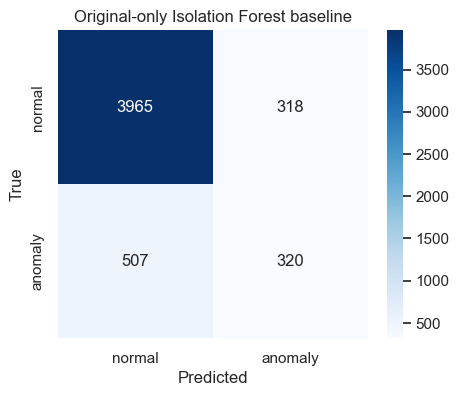

,model,data,features,window_size,stride,threshold_percentile,precision,recall,f1,auroc,auprc
0,IsolationForest,original_only,"RealPower,GateOnTime,SetPower,Speed,Length",30,1,5,0.501567,0.386941,0.43686,0.721021,0.521124


In [8]:
print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["normal", "anomaly"], yticklabels=["normal", "anomaly"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Original-only Isolation Forest baseline")
plt.show()

anomaly_score = -test_scores
metrics = {
    "model": "IsolationForest",
    "data": "original_only",
    "features": ",".join(FEATURES),
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "threshold_percentile": 5,
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "auroc": roc_auc_score(y_test, anomaly_score) if len(np.unique(y_test)) == 2 else np.nan,
    "auprc": average_precision_score(y_test, anomaly_score) if len(np.unique(y_test)) == 2 else np.nan,
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(BASELINE_DIR / "original_only_isolation_forest_metrics.csv", index=False)
display(metrics_df)

## 8. Baseline threshold 튜닝

먼저 모델을 다시 학습하지 않고, 정상 calibration score의 하위 몇 %를 이상 기준으로 볼지 조정합니다. 현재 baseline은 5% 기준입니다.

In [9]:
threshold_percentiles = [1, 3, 5, 7, 10, 15, 20, 25]
threshold_rows = []

for percentile in threshold_percentiles:
    tuned_threshold = np.percentile(calib_scores, percentile)
    tuned_pred = (test_scores < tuned_threshold).astype(int)
    tuned_anomaly_score = -test_scores

    threshold_rows.append({
        "model": "IsolationForest",
        "tuning_type": "threshold_only",
        "threshold_percentile": percentile,
        "threshold": tuned_threshold,
        "pred_normal": int((tuned_pred == 0).sum()),
        "pred_anomaly": int((tuned_pred == 1).sum()),
        "precision": precision_score(y_test, tuned_pred, zero_division=0),
        "recall": recall_score(y_test, tuned_pred, zero_division=0),
        "f1": f1_score(y_test, tuned_pred, zero_division=0),
        "auroc": roc_auc_score(y_test, tuned_anomaly_score),
        "auprc": average_precision_score(y_test, tuned_anomaly_score),
    })

threshold_tuning_df = pd.DataFrame(threshold_rows).sort_values("f1", ascending=False)
threshold_tuning_df.to_csv(BASELINE_DIR / "threshold_tuning_results.csv", index=False)
display(threshold_tuning_df)

,model,tuning_type,threshold_percentile,threshold,pred_normal,pred_anomaly,precision,recall,f1,auroc,auprc
0,IsolationForest,threshold_only,1,-0.080901,4762,348,0.778736,0.327690,0.461277,0.721021,0.521124
1,IsolationForest,threshold_only,3,-0.079723,4647,463,0.628510,0.351874,0.451163,0.721021,0.521124
2,IsolationForest,threshold_only,5,-0.078552,4472,638,0.501567,0.386941,0.436860,0.721021,0.521124
3,IsolationForest,threshold_only,7,-0.078183,4344,766,0.450392,0.417170,0.433145,0.721021,0.521124
4,IsolationForest,threshold_only,10,-0.077078,4199,911,0.399561,0.440145,0.418872,0.721021,0.521124
5,IsolationForest,threshold_only,15,-0.075211,3959,1151,0.346655,0.482467,0.403438,0.721021,0.521124
6,IsolationForest,threshold_only,20,-0.073720,3668,1442,0.307906,0.536880,0.391362,0.721021,0.521124
7,IsolationForest,threshold_only,25,-0.072330,3444,1666,0.281513,0.567110,0.376254,0.721021,0.521124


## 9. Isolation Forest 하이퍼파라미터 튜닝

작은 범위에서 `n_estimators`, `max_samples`, `threshold_percentile`을 비교합니다. 최종 비교는 F1 기준으로 정렬하되, 제조 이상 탐지에서는 recall도 함께 확인합니다.

In [10]:
param_rows = []

n_estimators_grid = [100, 300, 500]
max_samples_grid = ["auto", 0.8]
threshold_grid = [3, 5, 7, 10, 15]

for n_estimators in n_estimators_grid:
    for max_samples in max_samples_grid:
        tuned_model = IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            contamination="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        tuned_model.fit(x_fit)

        tuned_calib_scores = tuned_model.decision_function(x_calib)
        tuned_test_scores = tuned_model.decision_function(x_test_flat)
        tuned_anomaly_score = -tuned_test_scores

        for threshold_percentile in threshold_grid:
            tuned_threshold = np.percentile(tuned_calib_scores, threshold_percentile)
            tuned_pred = (tuned_test_scores < tuned_threshold).astype(int)

            param_rows.append({
                "model": "IsolationForest",
                "tuning_type": "model_and_threshold",
                "n_estimators": n_estimators,
                "max_samples": max_samples,
                "threshold_percentile": threshold_percentile,
                "threshold": tuned_threshold,
                "pred_normal": int((tuned_pred == 0).sum()),
                "pred_anomaly": int((tuned_pred == 1).sum()),
                "precision": precision_score(y_test, tuned_pred, zero_division=0),
                "recall": recall_score(y_test, tuned_pred, zero_division=0),
                "f1": f1_score(y_test, tuned_pred, zero_division=0),
                "auroc": roc_auc_score(y_test, tuned_anomaly_score),
                "auprc": average_precision_score(y_test, tuned_anomaly_score),
            })

if_tuning_df = pd.DataFrame(param_rows).sort_values("f1", ascending=False)
if_tuning_df.to_csv(BASELINE_DIR / "isolation_forest_tuning_results.csv", index=False)
display(if_tuning_df.head(10))

,model,tuning_type,n_estimators,max_samples,threshold_percentile,threshold,pred_normal,pred_anomaly,precision,recall,f1,auroc,auprc
16,IsolationForest,model_and_threshold,300,0.8,5,-0.111318,4475,635,0.540157,0.414752,0.469220,0.768062,0.560087
26,IsolationForest,model_and_threshold,500,0.8,5,-0.108816,4390,720,0.502778,0.437727,0.468003,0.769307,0.559067
5,IsolationForest,model_and_threshold,100,0.8,3,-0.114518,4565,545,0.587156,0.386941,0.466472,0.761035,0.553712
25,IsolationForest,model_and_threshold,500,0.8,3,-0.110812,4529,581,0.559380,0.392987,0.461648,0.769307,0.559067
15,IsolationForest,model_and_threshold,300,0.8,3,-0.114671,4593,517,0.589942,0.368803,0.453869,0.768062,0.560087
10,IsolationForest,model_and_threshold,300,auto,3,-0.079723,4647,463,0.628510,0.351874,0.451163,0.721021,0.521124
7,IsolationForest,model_and_threshold,100,0.8,7,-0.112413,4287,823,0.450790,0.448609,0.449697,0.761035,0.553712
6,IsolationForest,model_and_threshold,100,0.8,5,-0.113412,4463,647,0.511592,0.400242,0.449118,0.761035,0.553712
27,IsolationForest,model_and_threshold,500,0.8,7,-0.107940,4295,815,0.445399,0.438936,0.442144,0.769307,0.559067
11,IsolationForest,model_and_threshold,300,auto,5,-0.078552,4472,638,0.501567,0.386941,0.436860,0.721021,0.521124


## 10. Tuned baseline 선택

In [11]:
best_tuned = if_tuning_df.iloc[0].copy()
best_tuned.to_frame().T.to_csv(BASELINE_DIR / "best_tuned_isolation_forest.csv", index=False)

print("Best tuned baseline by F1")
display(best_tuned.to_frame().T)

print("Original baseline")
display(metrics_df[["precision", "recall", "f1", "auroc", "auprc"]])

Best tuned baseline by F1


,model,tuning_type,n_estimators,max_samples,threshold_percentile,threshold,pred_normal,pred_anomaly,precision,recall,f1,auroc,auprc
16,IsolationForest,model_and_threshold,300,0.8,5,-0.111318,4475,635,0.540157,0.414752,0.46922,0.768062,0.560087


Original baseline


,precision,recall,f1,auroc,auprc
0,0.501567,0.386941,0.43686,0.721021,0.521124
